In [1]:
import math

import numpy as np
import SimpleITK as sitk
import pyvista as pv
import point_cloud_utils as pcu
import pandas as pd

from morphometry import hip, utils
from morphometry.image_io import Image, Segmentation
from matplotlib import pyplot as plt
from scipy.spatial import KDTree
from scipy.ndimage import center_of_mass
from sklearn.cluster import KMeans
from skimage.measure import find_contours
from pathlib import Path

In [2]:
import importlib
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [3]:
pv.set_jupyter_backend('trame')

# Femoral head center

In [17]:
mask = Segmentation('nibabel')
# mask.read_image('/home/simon/Data/Hamburg/100000_30_PD_FS_SPC_COR/100000_30_PD_FS_SPC_COR.nii')
# mask.read_image('/home/simon/Data/Hamburg/100050_PD_FS_SPC_COR/100050_PD_FS_SPC_COR.nii.gz')
mask.read_image('/home/simon/Data/Augsburg_large/preprocessed/PA000030/hip_seg.nii.gz')
mask.remove_outliers()
mask.get_shape()

(384, 324, 16)

In [5]:
mask.get_direction(), mask.get_origin(), mask.get_spacing()

(array([[-1.,  0.,  0.],
        [ 0.,  0., -1.],
        [ 0., -1.,  0.]]),
 array([ 176.44444275,   38.38888931, -565.5       ]),
 (1.0, 1.0, 1.0))

In [6]:
mask.transform_coordinate_system(('L', 'I', 'P'))
mask.get_shape(), mask.get_direction(), mask.get_origin(), mask.get_spacing()

((384, 264, 160),
 array([[-1.,  0.,  0.],
        [ 0.,  0., -1.],
        [ 0., -1.,  0.]]),
 array([ 176.44444275,   38.38888931, -565.5       ]),
 (1.0, 1.0, 1.0))

In [7]:
mask.get_transversal_axis(), mask.get_coronal_axis(), mask.get_sagittal_axis()

(1, 2, 0)

In [8]:
mask.get_transversal_axis_direction(), mask.get_coronal_axis_direction(), mask.get_sagittal_axis_direction()

(1, 1, 1)

In [9]:
mask.transform_index_to_physical_point(np.array([0, 0, 0]).T), mask.transform_index_to_physical_point(np.array([384, 0, 0]).T)  # first component should change and

(array([ 176.44444275,   38.38888931, -565.5       ]),
 array([-207.55555725,   38.38888931, -565.5       ]))

In [10]:
mask.transform_index_to_physical_point(np.array([0, 0, 0]).T), mask.transform_index_to_physical_point(np.array([0, 264, 0]).T)

(array([ 176.44444275,   38.38888931, -565.5       ]),
 array([ 176.44444275,   38.38888931, -829.5       ]))

In [11]:
mask.transform_index_to_physical_point(np.array([0, 0, 0]).T), mask.transform_index_to_physical_point(np.array([0, 0, 160]).T)

(array([ 176.44444275,   38.38888931, -565.5       ]),
 array([ 176.44444275, -121.61111069, -565.5       ]))

In [18]:
mask.transform_coordinate_system(('L', 'P', 'I'))
mask.get_shape(), mask.get_direction(), mask.get_origin(), mask.get_spacing()

((384, 324, 16),
 array([[ -1.09375,   0.     ,   0.     ],
        [  0.     ,  -1.09375,   0.     ],
        [  0.     ,   0.     , -10.     ]]),
 array([227.13070679, 161.82800293, 630.4503479 ]),
 (1.09375, 1.09375, 10.0))

In [19]:
mask.transform_index_to_physical_point(np.array([0, 0, 0]).T), mask.transform_index_to_physical_point(np.array([mask.get_shape()[0], 0, 0]).T)

(array([227.13070679, 161.82800293, 630.4503479 ]),
 array([-192.86929321,  161.82800293,  630.4503479 ]))

In [20]:
mask.transform_index_to_physical_point(np.array([0, 0, 0]).T), mask.transform_index_to_physical_point(np.array([0, mask.get_shape()[1], 0]).T)

(array([227.13070679, 161.82800293, 630.4503479 ]),
 array([ 227.13070679, -192.54699707,  630.4503479 ]))

In [21]:
mask.transform_index_to_physical_point(np.array([0, 0, 0]).T), mask.transform_index_to_physical_point(np.array([0, 0, mask.get_shape()[2]]).T)

(array([227.13070679, 161.82800293, 630.4503479 ]),
 array([227.13070679, 161.82800293, 470.4503479 ]))

In [15]:
affine = mask.get_affine()
M = affine[:3, :3]
abc = affine[:3, 3]
M, abc

(array([[ 1.,  0.,  0.],
        [ 0., -1.,  0.],
        [ 0.,  0., -1.]]),
 array([-206.55555725,   38.38888931, -565.5       ]))

In [18]:
np.argwhere(M)

array([[0, 0],
       [1, 1],
       [2, 2]])

In [16]:
index = np.array([384, 160, 264])
tmp = np.dot(M, index)
tmp

array([ 384., -160., -264.])

In [17]:
tmp + abc

array([ 177.44444275, -121.61111069, -829.5       ])

In [7]:
spacing = mask.get_spacing()
x_ratio = abs(spacing[0]) / 2 * abs(spacing[2])
spacing, x_ratio

((1.0, 1.0, 1.0), 0.5)

In [8]:
mask_array = mask.get_array()
mask_array = np.where(mask_array == 1, 1, 0)

In [9]:
mask_array.shape

(264, 160, 384)

In [35]:
mask.transform_index_to_physical_point((0, 0, 0)), mask.transform_index_to_physical_point((264, 0, 0))

(array([-206.55555725,   38.38888931, -565.5       ]),
 array([-206.55555725,   38.38888931, -829.5       ]))

In [10]:
right_mask = mask_array[:, :, mask_array.shape[2] // 2:]

In [11]:
from morphometry.utils import get_contour_points
from scipy.stats import zscore
from scipy.ndimage import label

segmentation_mask = right_mask
isotropic = True
side = 'right'
x_ratio = 1

contour_pts = get_contour_points(segmentation_mask)

# get highest layer with a mask point, its centroid
# and lowest layer with mask point on this centroid
layer_high = np.amin(contour_pts[:, 0])
layer_sizes = np.zeros(segmentation_mask.shape[0])
for i, layer in enumerate(segmentation_mask):
    layer_sizes[i] = np.sum(layer)

layer_zscores = np.abs(zscore(layer_sizes))
while layer_zscores[layer_high] > 2:
    # print(f'Layer {layer_high} has too few mask points, going to the next layer.')
    layer_high += 1  # go to the next layer if the current one has too few mask points, i.e. its size is more than 2 standard deviations away from the mean of all slices

# if layer_high has two connected components, choose the larger one
label_mask, num_features = label(segmentation_mask[layer_high])
if num_features > 1:
    # print('Multiple connected components found on layer with femoral head, choosing the largest one.')
    sizes = [len(np.argwhere(label_mask == i)) for i in range(1, num_features + 1)]
    largest_component = np.argmax(sizes) + 1
    segmentation_mask[layer_high] = np.where(label_mask == largest_component, 1, 0)

com_high = center_of_mass(segmentation_mask[layer_high])
com_high = (int(com_high[0]), int(com_high[1]))
layer_low = layer_high
while segmentation_mask[layer_low, com_high[0], com_high[1]] != 0:
    layer_low += 1

point_cloud = get_contour_points(segmentation_mask)
point_cloud = point_cloud[point_cloud[:, 0] >= layer_high]
point_cloud = point_cloud[point_cloud[:, 0] <= layer_low]
point_cloud = point_cloud.astype(np.float32) * np.array([x_ratio, 1, 1])

# need to exclude lateral parts of the mask: compute distance between com and max medial point of femoral head,
# then exclude everything that is farther away than this distance in the lateral direction
middle_slice = (layer_high * x_ratio + (layer_low * x_ratio - layer_high * x_ratio) // 2)
superior_half = point_cloud[point_cloud[:, 0] <= middle_slice]
if side == 'left':
    max_z = np.max(point_cloud[:, 2]) if isotropic else np.max(superior_half[:, 2]) * 0.9  # only look at the superior half of the femoral head
    radius = max_z - com_high[1]
    min_z = com_high[1] - radius  # the most lateral point of the femoral head
    point_cloud = point_cloud[point_cloud[:, 2] >= min_z]
else:
    min_z = np.min(point_cloud[:, 2]) if isotropic else np.min(superior_half[:, 2]) * 0.9 # only look at the superior half of the femoral head
    radius = com_high[1] - min_z
    max_z = com_high[1] + radius  # the most lateral point of the femoral head
    point_cloud = point_cloud[point_cloud[:, 2] <= max_z]

min_y = np.min(point_cloud[:, 1])
radius = com_high[0] - min_y
max_y = com_high[0] + radius
contour = point_cloud[point_cloud[:, 1] <= max_y]

In [12]:
r, c, layer_high, layer_low = hip.get_femoral_head_center(right_mask, side='right', x_ratio=1, isotropic=True, return_layers=True)

In [13]:
r, c

(22.179380426382515, array([168.20682268,  70.57540864,  85.24657548]))

In [14]:
layer_high, layer_low

(145, 187)

In [15]:
point_cloud = np.argwhere(right_mask)
idx = pcu.downsample_point_cloud_poisson_disk(point_cloud.astype('float32'), radius=0, target_num_samples=5000)

In [20]:
p = pv.Plotter()
# p.add_mesh(pv.PolyData(contour), color='b')
p.add_mesh(pv.PolyData(point_cloud), opacity=1, color='green')
p.add_mesh(pv.Sphere(r, c), opacity=1, color='r')
p.enable_eye_dome_lighting()
p.show()

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:37325/index.html?ui=P_0x70280c10f430_4&reconnect=auto" class="pyvi…

# Femoral shaft axis

In [21]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [22]:
knee = Segmentation('nibabel')
knee.read_image('/home/simon/Data/Augsburg_large/preprocessed/PA000030/knee_seg.nii.gz')
knee.remove_outliers()
knee.transform_coordinate_system()
knee_mask = knee.get_array()
right_knee = knee_mask[:, :, knee_mask.shape[2] // 2:]

In [39]:
knee.get_shape(), knee.get_spacing()

((26, 324, 384), (3.9999998, 1.09375, 1.09375))

In [37]:
knee.transform_index_to_physical_point((0, 0, 0)), knee.transform_index_to_physical_point((26, 0, 0))

(array([-202.41384888,  165.88989258,  221.8913362 ]),
 array([-202.41384888,  165.88989258,  117.8913424 ]))

In [38]:
knee.transform_index_to_physical_point((0, 0, 0)), knee.transform_index_to_physical_point((0, 324, 0))

(array([-202.41384888,  165.88989258,  221.8913362 ]),
 array([-202.41384888, -188.48510742,  221.8913362 ]))

In [40]:
knee.transform_index_to_physical_point((0, 0, 0)), knee.transform_index_to_physical_point((0, 0, 384))

(array([-202.41384888,  165.88989258,  221.8913362 ]),
 array([217.58615112, 165.88989258, 221.8913362 ]))

In [41]:
knee.read_image('/home/simon/Data/Augsburg_large/preprocessed/PA000030/knee_seg.nii.gz')
knee.remove_outliers()
knee.get_shape()

(384, 324, 26)

In [43]:
knee.transform_index_to_physical_point((0, 0, 0)), knee.transform_index_to_physical_point((384, 0, 0))

(array([216.49240112, 165.88989258, 121.89134216]),
 array([-203.50759888,  165.88989258,  121.89134216]))

In [44]:
knee.transform_index_to_physical_point((0, 0, 0)), knee.transform_index_to_physical_point((0, 324, 0))

(array([216.49240112, 165.88989258, 121.89134216]),
 array([ 216.49240112, -188.48510742,  121.89134216]))

In [45]:
knee.transform_index_to_physical_point((0, 0, 0)), knee.transform_index_to_physical_point((0, 0, 26))

(array([216.49240112, 165.88989258, 121.89134216]),
 array([216.49240112, 165.88989258, 225.89133596]))

In [23]:
p0, p1 = hip.get_femoral_shaft_axis(right_mask, right_knee, isotropic=False)

In [24]:
p0, p1

(array([  1, 155,  72]), array([257,  54, 123]))

In [25]:
p0 = knee.transform_index_to_physical_point(p0)
p1 = mask.transform_index_to_physical_point(p1)
print(p0, p1)

[-123.66384888   -3.64135742  217.89133644] [ -83.55555725  -15.61111069 -822.5       ]


In [26]:
p3 = p0 - p1
p3

array([ -40.10829163,   11.96975327, 1040.39133644])

In [27]:
from skimage import measure
femur_contour = []
last_slice = False
stop = False
for i, sl in enumerate(right_mask):
    if np.sum(sl) > 0 and np.sum(sl + 1) == 0:
        for coord in np.argwhere(sl == 1):
            femur_contour.append([i, coord[0], coord[1]])  # swap x and y back to original order
    else:
        contours = measure.find_contours(np.where(sl == 1, 1, 0), 0.8)
        for contour in contours:
            for coord in contour:
                femur_contour.append([i, coord[0], coord[1]])

femur_contour = np.array(femur_contour).astype(np.float32)

In [28]:
femur_contour

array([[145. ,  72.2,  85. ],
       [145. ,  72.2,  84. ],
       [145. ,  72.2,  83. ],
       ...,
       [263. ,  59.2, 115. ],
       [263. ,  60. , 114.2],
       [263. ,  60.2, 114. ]], dtype=float32)

In [29]:
femur_contour = np.array([mask.transform_index_to_physical_point(x) for x in femur_contour])

In [30]:
femur_contour

array([[-121.55555725,  -33.81110764, -710.5       ],
       [-122.55555725,  -33.81110764, -710.5       ],
       [-123.55555725,  -33.81110764, -710.5       ],
       ...,
       [ -91.55555725,  -20.81111145, -828.5       ],
       [ -92.3555603 ,  -21.61111069, -828.5       ],
       [ -92.55555725,  -21.81111145, -828.5       ]])

In [31]:
knee_cloud = np.argwhere(right_knee)
knee_cloud = np.array([knee.transform_index_to_physical_point(x) for x in knee_cloud])

In [32]:
# idx = pcu.downsample_point_cloud_poisson_disk(femur_contour, radius=0, target_num_samples=20000)
surface_mesh = pv.PolyData(femur_contour).reconstruct_surface()

In [33]:
p = pv.Plotter()
# p.add_mesh(surface_mesh, opacity=.5)
p.add_mesh(pv.PolyData(femur_contour), color='b')
p.add_mesh(pv.PolyData(knee_cloud))
# p.add_lines(np.array([p0, p1 - 3 * p3]), color='g')
p.add_lines(np.array([p0, p1]), color='y')
p.enable_eye_dome_lighting()
p.show()

Widget(value='<iframe src="http://localhost:37325/index.html?ui=P_0x70280c10faf0_5&reconnect=auto" class="pyvi…

# Femoral neck axis

In [28]:
solid_sphere = pv.SolidSphere(inner_radius=1.1*r, outer_radius=1.2 * r, center=c)
points_i_want = np.array(solid_sphere.points)
points_i_want = points_i_want[points_i_want[:, 0] > c[0]]
points_i_want = points_i_want[points_i_want[:, 2] > c[2]]

In [29]:
tmp = pv.PolyData(point_cloud[idx])

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


In [30]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(points_i_want), color='r', opacity=0.5)
p.show()

Widget(value='<iframe src="http://localhost:35105/index.html?ui=P_0x76653e1642e0_2&reconnect=auto" class="pyvi…

In [31]:
pc_tree = KDTree(point_cloud)
sphere_tree = KDTree(points_i_want)

In [32]:
pairs = pc_tree.query_ball_tree(sphere_tree, 1.5)

In [33]:
neck_points = list()
for pair in pairs:
    if len(pair) > 0:
        for index in pair:
            neck_points.append(sphere_tree.data[index])

neck_points = np.array(neck_points)

In [34]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.show()

Widget(value='<iframe src="http://localhost:35105/index.html?ui=P_0x76653e1433a0_3&reconnect=auto" class="pyvi…

In [35]:
com = KMeans(n_clusters=1).fit(neck_points).cluster_centers_

In [36]:
com

array([[178.926902  ,  73.04852047, 105.39748009]])

In [37]:
distances = np.linalg.norm(neck_points - com, axis=1)
distances

array([12.44180663, 12.44180663, 12.65593339, ..., 19.60244257,
       19.60244257, 19.96670131])

In [38]:
array_mask = np.abs(distances - np.mean(distances)) < 2 * np.std(distances)
neck_points = neck_points[array_mask]

In [39]:
com = KMeans(n_clusters=1).fit(neck_points).cluster_centers_

In [40]:
neck_axis = c - com[0]

In [41]:
p = pv.Plotter()
p.add_mesh(tmp, color='b', opacity=.2)
p.add_mesh(pv.PolyData(neck_points), color='r')
p.add_mesh(pv.Sphere(5, com[0]), color='g')
p.add_lines(np.array([c, com[0] - 3 * neck_axis]), color='y', width=5)
p.add_lines(np.array([p0, p1 - 3 * p3]), color='g')
p.add_lines(np.array([p0, p1]), color='y')
p.show()

NameError: name 'p0' is not defined

# CCD

In [39]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [66]:
hip.calculate_ccd(mask_array[:, :, :mask_array.shape[2] // 2])

92.27907953616051

In [40]:
segmentations = list()
for path in Path('/home/simon/Data/Hamburg').iterdir():
    for file in path.iterdir():
        if 'Segmentation' in file.name:
            segmentations.append(file)

# Alpha angle

In [42]:
most_proximal_points = neck_points[neck_points[:, 0] == neck_points[:, 0].min()]
most_proximal_lateral_point = most_proximal_points[most_proximal_points[:, 2] == most_proximal_points[:, 2].max()]
most_proximal_lateral_point

In [50]:
most_distal_points = neck_points[neck_points[:, 0] == neck_points[:, 0].max()]
most_distal_medial_point = most_distal_points[most_distal_points[:, 2] == most_distal_points[:, 2].min()]
most_distal_medial_point

array([[192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743],
       [192.93177637,  70.57540864,  95.09789743]])

In [53]:
most_posterior_points = neck_points[neck_points[:, 1] == neck_points[:, 1].max()]
most_posterior_points

array([[183.43004623,  88.49757292,  97.71338628],
       [183.43004623,  88.49757292,  97.71338628],
       [183.43004623,  88.49757292,  97.71338628],
       [183.43004623,  88.49757292,  97.71338628]])

In [54]:
most_anterior_points = neck_points[neck_points[:, 1] == neck_points[:, 1].min()]
most_anterior_points

array([[175.12269908,  57.53068192, 104.66911153]])

In [56]:
neck_axis = c - com[0]
v1 = c - most_proximal_lateral_point[0]
v2 = c - most_distal_medial_point[0]
v3 = c - most_posterior_points[0]
v4 = c - most_anterior_points[0]
v1, v2, v3, v4

(array([ -0.14280838,   2.63394554, -24.25430034]),
 array([-24.72495369,   0.        ,  -9.85132195]),
 array([-15.22322355, -17.92216428, -12.4668108 ]),
 array([ -6.91587641,  13.04472672, -19.42253605]))

In [57]:
a1 = utils.calculate_angle_between_vectors(neck_axis, v1)
a2 = utils.calculate_angle_between_vectors(neck_axis, v2)
a3 = utils.calculate_angle_between_vectors(neck_axis, v3)
a4 = utils.calculate_angle_between_vectors(neck_axis, v4)
a1, a2, a3, a4

(28.300790704125202, 42.46896764563891, 42.70789106073521, 38.42458003375945)

In [58]:
np.array([a1, a2, a3, a4]).mean()

37.975557361064695

In [60]:
p = pv.Plotter()
p.add_mesh(tmp, color='b', opacity=.2)
p.add_mesh(pv.PolyData(neck_points), color='r')
p.add_mesh(pv.Sphere(5, com[0]), color='g')
p.add_lines(np.array([c, com[0] - 3 * neck_axis]), color='g', width=5)
p.add_lines(np.array([c, most_proximal_lateral_point[0]]), color='y', width=5)
p.add_lines(np.array([c, most_distal_medial_point[0]]), color='y', width=5)
p.add_lines(np.array([c, most_posterior_points[0]]), color='y', width=5)
p.add_lines(np.array([c, most_anterior_points[0]]), color='y', width=5)
p.enable_eye_dome_lighting()
p.show()

Widget(value='<iframe src="http://localhost:35105/index.html?ui=P_0x76653b4d0580_11&reconnect=auto" class="pyv…

In [108]:
p.close()

# Acetabular Anteversion

In [75]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [77]:
mask = sitk.ReadImage('/home/simon/Data/Hamburg/100000_30_PD_FS_SPC_COR/100000_30_PD_FS_SPC_COR.nii')
spacing = mask.GetSpacing()
z_ratio = abs(spacing[2]) / 2 * abs(spacing[0])
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.swapaxes(mask_array, 0, 1)

In [78]:
mask_array.shape

(264, 160, 384)

In [79]:
femur_array = np.where(mask_array == 1, 1, 0)

In [80]:
acetabulum_array = np.where(mask_array == 3, 3, 0)

In [81]:
left_femur = femur_array[:, :, :femur_array.shape[2] // 2]
right_femur = femur_array[:, :, femur_array.shape[2] // 2:]

In [82]:
left_acetabulum = acetabulum_array[:, :, :acetabulum_array.shape[2] // 2]
right_acetabulum = acetabulum_array[:, :, acetabulum_array.shape[2] // 2:]

In [83]:
left_femur.shape

(264, 160, 192)

In [84]:
lr, left_fhc = hip.get_femoral_head_center(left_femur, 'left')
rr, right_fhc = hip.get_femoral_head_center(right_femur, 'right')

In [85]:
left_fhc, right_fhc

(array([183.69751754,  58.10219419,  98.7394926 ]),
 array([189.22227829,  57.36492729,  92.6464867 ]))

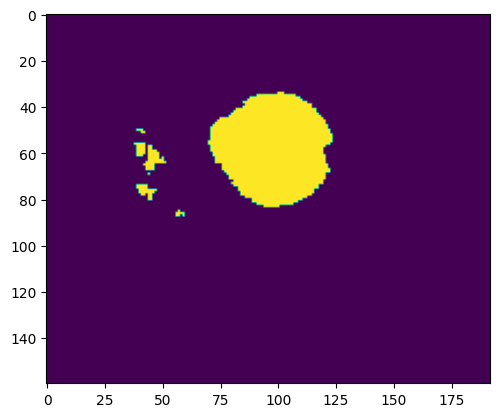

In [86]:
plt.imshow(left_femur[int(left_fhc[0])])

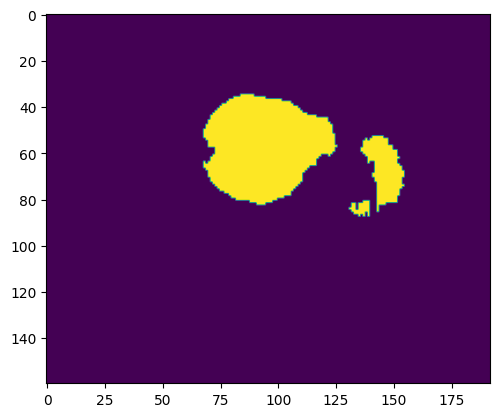

In [87]:
plt.imshow(right_femur[int(right_fhc[0])])

In [88]:
slice_gap = abs(int(left_fhc[0]) - int(right_fhc[0]))
slice_gap

6

In [89]:
correct_slice = min(int(left_fhc[0]), int(right_fhc[0])) + slice_gap // 2
correct_slice

186

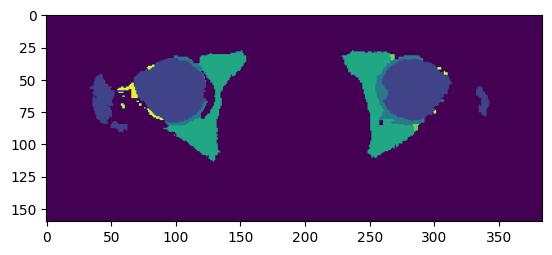

In [90]:
plt.imshow(mask_array[correct_slice])

Do left side first

In [91]:
p1_left = np.argwhere(left_acetabulum[correct_slice])
p1_left = p1_left[p1_left[:, 1].argmin()]
p1_left

array([88, 91])

In [92]:
p2_left = np.argwhere(left_acetabulum[correct_slice][:left_acetabulum.shape[1] // 3])
p2_left = p2_left[p2_left[:, 1].argmin()]
p2_left

array([ 38, 118])

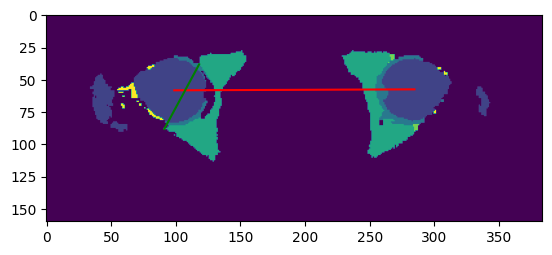

In [93]:
plt.imshow(mask_array[correct_slice])
plt.plot([left_fhc[2], right_fhc[2] + left_femur.shape[2]], [left_fhc[1], right_fhc[1]], 'r')
plt.plot([p1_left[1], p2_left[1]], [p1_left[0], p2_left[0]], 'g')
plt.show()

In [94]:
right_fhc_adj = right_fhc.copy()
right_fhc_adj[2] += left_femur.shape[2]
G = left_fhc[1:] - right_fhc_adj[1:]
G

array([   0.73726689, -185.9069941 ])

In [95]:
# https://math.stackexchange.com/questions/1398634/finding-a-perpendicular-vector-from-a-line-to-a-point
u = left_fhc[1:]
v = G
P = p1_left
P_  = np.dot(np.dot((P - u), v) / np.dot(v, v), v) + u
t = P - P_
t

array([29.86664293,  0.11844464])

In [96]:
np.dot(G, t)

np.float64(-2.1316282072803006e-13)

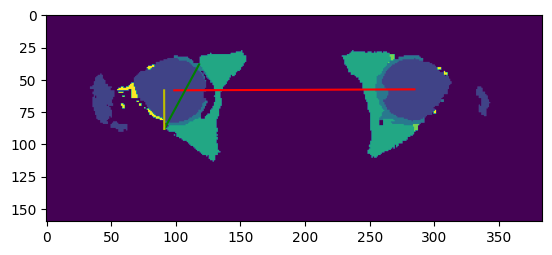

In [97]:
plt.imshow(mask_array[correct_slice])
plt.plot([left_fhc[2], right_fhc[2] + left_femur.shape[2]], [left_fhc[1], right_fhc[1]], 'r')
plt.plot([p1_left[1], p2_left[1]], [p1_left[0], p2_left[0]], 'g')
plt.plot([p1_left[1], p1_left[1] - t[1]], [p1_left[0], p1_left[0] - t[0]], 'y')
plt.show()

In [98]:
v1 = (p1_left - p2_left).astype('float32')
v2 = t.copy()
v1 /= np.linalg.norm(v1)
v2 /= np.linalg.norm(v2)
math.degrees(np.arccos(np.dot(v1, v2)))

28.59626716249661

Then right side

In [99]:
p1_right = np.argwhere(right_acetabulum[correct_slice])
p1_right = p1_right[p1_right[:, 1].argmax()]
p1_right

array([87, 92])

In [100]:
p2_right = np.argwhere(right_acetabulum[correct_slice][:right_acetabulum.shape[1] // 3])
p2_right = p2_right[p2_right[:, 1].argmax()]
p2_right

array([33, 74])

In [101]:
u = right_fhc[1:]
v = G
P = p1_right
P_  = np.dot(np.dot((P - u), v) / np.dot(v, v), v) + u
t = P - P_
t

array([29.63204284,  0.11751427])

In [102]:
np.dot(G, t)

np.float64(9.841016890277388e-13)

In [103]:
plt.show()
v1 = (p1_right - p2_right).astype('float32')
v2 = t.copy()
v1 /= np.linalg.norm(v1)
v2 /= np.linalg.norm(v2)
math.degrees(np.arccos(np.dot(v1, v2)))

18.207723061604835

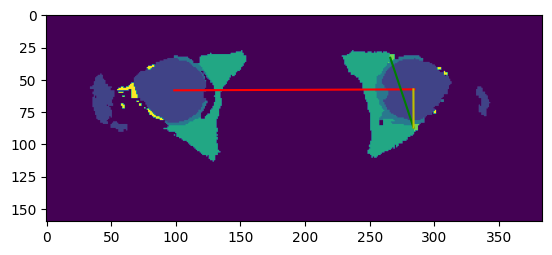

In [104]:
plt.imshow(mask_array[correct_slice])
plt.plot([left_fhc[2], right_fhc[2] + left_femur.shape[2]], [left_fhc[1], right_fhc[1]], 'r')
plt.plot([p1_right[1] + left_femur.shape[2], p2_right[1] + left_femur.shape[2]], [p1_right[0], p2_right[0]], 'g')
plt.plot([p1_right[1] + left_femur.shape[2], p1_right[1] + left_femur.shape[2] - t[1]], [p1_right[0], p1_right[0] - t[0]], 'y')
plt.show()

# Center Edge Angle

In [2]:
mask = sitk.ReadImage('/home/simon/Data/Hamburg/100000_30_PD_FS_SPC_COR/100000_30_PD_FS_SPC_COR.nii')
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.swapaxes(mask_array, 0, 1)

In [3]:
importlib.reload(hip)

NameError: name 'importlib' is not defined

In [4]:
femur_array = np.where(mask_array == 1, 1, 0)
acetabulum_array = np.where(mask_array == 3, 1, 0)

left_femur = femur_array[:, :, :femur_array.shape[2] // 2]
right_femur = femur_array[:, :, femur_array.shape[2] // 2:]

left_acetabulum = acetabulum_array[:, :, :acetabulum_array.shape[2] // 2]
right_acetabulum = acetabulum_array[:, :, acetabulum_array.shape[2] // 2:]

_, left_fhc = hip.get_femoral_head_center(left_femur, 'left')
_, right_fhc = hip.get_femoral_head_center(right_femur, 'right')

right_fhc_adj = right_fhc.copy()
right_fhc_adj[2] += left_femur.shape[
    2]  # adjust the x coordinate of the right femoral head center to account for the splitting into left and right
G = left_fhc - right_fhc_adj  # G is the vector connecting the left and right femoral head center

In [67]:
u = right_fhc
v = G
p = right_fhc + np.array([-1, 0, 0])
# s = hip.get_vector_through_point_perpendicular_to_line(u, v, p)  # s is perpendicular to G and goes in proximal direction
d = np.array([-1, 0, 0])
n = G / np.linalg.norm(G)
d_perp = d - np.dot(d, n) * n
s = right_fhc_adj + d_perp
s, np.dot(G, s)

(array([188.01229226,  57.33085916, 284.96708666]), -54008.28860159089)

In [100]:
most_proximal_femur_slice = np.min(np.nonzero(right_femur)[0])
tmp = right_acetabulum.copy()
tmp[:most_proximal_femur_slice - 20] = 0
tmp[most_proximal_femur_slice + 10:] = 0
acetabulum_points = np.nonzero(tmp)
lateral_edge = np.argmax(acetabulum_points[2])
lateral_edge_point = np.array([acetabulum_points[0][lateral_edge], acetabulum_points[1][lateral_edge], acetabulum_points[2][lateral_edge]])
lateral_edge, lateral_edge_point

(17, array([144,  26, 108]))

In [101]:
acetabulum_points

(array([144, 144, 144, ..., 173, 173, 173]),
 array([ 25,  25,  25, ..., 105, 105, 105]),
 array([ 99, 100, 101, ...,  65,  66,  67]))

In [102]:
s2 = right_fhc - lateral_edge_point


In [103]:
utils.calculate_angle_between_vectors(s, s2)

72.35991132967483

In [104]:
s2

array([ 45.01135721,  31.33097837, -15.06347728])

In [105]:
s

array([188.01229226,  57.33085916, 284.96708666])

In [106]:
h = s - right_fhc_adj
h

array([-9.99064957e-01, -1.19210511e-04,  3.05639375e-02])

In [107]:
tmp = acetabulum_array.copy()
tmp[:most_proximal_femur_slice - 20] = 0
tmp[most_proximal_femur_slice + 10:] = 0

In [110]:
p = pv.Plotter()
p.add_lines(np.array([left_fhc, right_fhc_adj]), color='y')
p.add_mesh(pv.PolyData(np.argwhere(tmp)), color='b', opacity=.2)
p.add_mesh(pv.PolyData(np.argwhere(femur_array)), color='g', opacity=.2)
p.add_lines(np.array([right_fhc_adj, right_fhc_adj + 100 * h]), color='r')
p.add_lines(np.array([left_fhc, left_fhc + 100 * h]), color='r')
p.add_lines(np.array([right_fhc_adj, lateral_edge_point + np.array([0, 0, left_femur.shape[2]])]), color='black')
p.enable_eye_dome_lighting()
p.show()

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:34933/index.html?ui=P_0x70a63b746320_24&reconnect=auto" class="pyv…

# Cartilage thickness

In [33]:
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.swapaxes(mask_array, 0, 1)
left_mask = mask_array[:, :, :mask_array.shape[2] // 2]
cartilage = np.argwhere(left_mask == 2)
sphere = pv.Sphere(radius=r, center=c)

In [34]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(cartilage), color='b')
p.add_mesh(sphere, color='r')
p.show()

/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:41929/index.html?ui=P_0x71d5c3f5a6b0_1&reconnect=auto" class="pyvi…

In [35]:
importlib.reload(utils)

<module 'morphometry.utils' from '/home/simon/Work/morpohmetry/morphometry/utils.py'>

In [36]:
cr, cc = utils.sphere_fit(cartilage)

In [37]:
cr, cc

(25.92961742279423, array([183.08593874,  58.76718884,  99.36089405]))

In [38]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(cartilage), color='b')
p.add_mesh(pv.Sphere(cr, cc), color='r')
p.show()

/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:41929/index.html?ui=P_0x71d5c0fc9360_2&reconnect=auto" class="pyvi…

In [39]:
len(cartilage)

13275

In [40]:
len(pv.Sphere(cr, cc, theta_resolution=15, phi_resolution=15).points), len(pv.Sphere(cr, cc, theta_resolution=30, phi_resolution=30).points)

(197, 842)

In [41]:
15 + 14 * 13

197

In [42]:
np.sqrt(197)  # required resolution can be approximated by sqrt(n)

14.035668847618199

In [43]:
resolution = int(np.sqrt(len(cartilage) * 2))  # assuming that about half of the sphere is covered by cartilage, it needs to have two times the points 
outer_sphere = pv.Sphere(radius=1.2 * cr, center=cc, theta_resolution=resolution, phi_resolution=resolution)
inner_sphere = pv.Sphere(radius=0.8 * cr, center=cc, theta_resolution=resolution, phi_resolution=resolution)
print(len(outer_sphere.points), len(inner_sphere.points))

25922 25922


In [44]:
inner_surface = dict()
outer_surface = dict()

cartilage_tree = KDTree(cartilage)

for point in inner_sphere.points:
    distance, index = cartilage_tree.query(point)
    if index in inner_surface.keys():
        if distance > inner_surface[index]:
            continue
    inner_surface[index] = distance
    
for point in outer_sphere.points:
    distance, index = cartilage_tree.query(point)
    if index in outer_surface.keys():
        if distance > outer_surface[index]:
            continue
    outer_surface[index] = distance

In [45]:
inner_distances = pd.Series(inner_surface.values())
outer_distances = pd.Series(outer_surface.values())

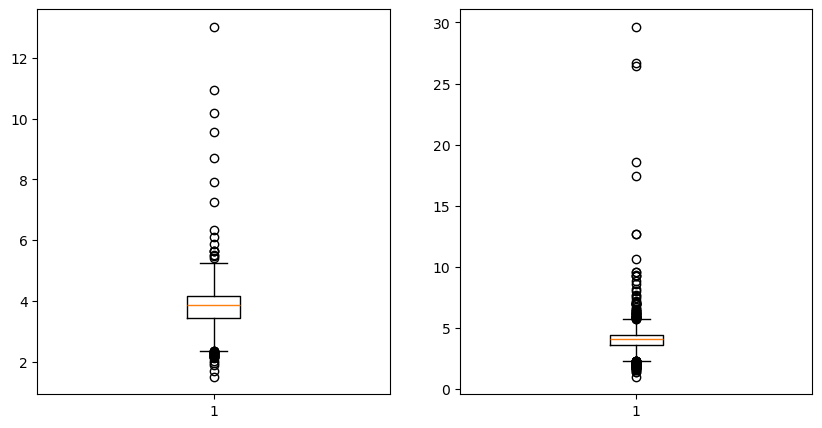

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(inner_distances)
ax[1].boxplot(outer_distances)
plt.show()

In [47]:
inner_distances.describe(), outer_distances.describe()

(count    1358.000000
 mean        3.818284
 std         0.759658
 min         1.504813
 25%         3.448854
 50%         3.855075
 75%         4.176435
 max        13.017364
 dtype: float64,
 count    1850.000000
 mean        4.083821
 std         1.422861
 min         1.006492
 25%         3.588835
 50%         4.092035
 75%         4.453516
 max        29.646105
 dtype: float64)

In [48]:
inner_surface_indices = [k for k, v in inner_surface.items() if v < inner_distances.quantile(0.75)]
outer_surface_indices = [k for k, v in outer_surface.items() if v < outer_distances.quantile(0.75)]

In [49]:
inner_surface_np = cartilage[inner_surface_indices]
outer_surface_np = cartilage[outer_surface_indices]

In [50]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(inner_surface_np), color='b')
p.add_mesh(pv.PolyData(outer_surface_np), color='r')
p.show()

/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:41929/index.html?ui=P_0x71d5c4bb3c70_3&reconnect=auto" class="pyvi…

In [51]:
outer_surface_tree = KDTree(outer_surface_np)
distances = np.empty(len(inner_surface_np))
for i, point in enumerate(inner_surface_np):
    distances[i] = outer_surface_tree.query(point)[0]

np.nanmean(distances)

3.416619259233876

In [52]:
inner_surface_mesh = pv.PolyData(inner_surface_np).reconstruct_surface()
outer_surface_mesh = pv.PolyData(outer_surface_np).reconstruct_surface()

/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


In [53]:
p = pv.Plotter()
p.add_mesh(inner_surface_mesh, color='b')
p.add_mesh(outer_surface_mesh, color='r')
p.show()

Widget(value='<iframe src="http://localhost:41929/index.html?ui=P_0x71d5c4a6a1d0_4&reconnect=auto" class="pyvi…

In [90]:
inner_surface_mesh = inner_surface_mesh.compute_normals(point_normals=True, cell_normals=False, auto_orient_normals=True)
distances = np.empty(len(inner_surface_mesh.points))
for i in range(len(inner_surface_mesh.points)):
    p = inner_surface_mesh.points[i]
    vec = inner_surface_mesh['Normals'][i] * inner_surface_mesh.length
    p0 = p - vec
    p1 = p + vec
    ip, ic = outer_surface_mesh.ray_trace(p0, p1, first_point=True)
    distances[i] = np.linalg.norm(ip - p)
    
np.nanmean(distances)

38.83942533763891

In [92]:
closest_cells, closest_points = outer_surface_mesh.find_closest_cell(inner_surface_mesh.points, return_closest_point=True)
d_exact = np.linalg.norm(inner_surface_mesh.points - closest_points, axis=1)
np.nanmean(d_exact)

2.787236175003177